In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import Bio
import Bio.Seq

## Import Dataset

In [2]:
df = pd.read_pickle("data/beta_activity.pkl")
df.head()

,sequence,count,response
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,17456,3
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,13670,3
2,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,11180,3
3,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,10159,3
4,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,3976,3


In [3]:
# number of sequences
Nseq = len(df)
Nseq

853

In [4]:
WT_DNA = 'ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAGCACGTGCAGAACATATGACCATTGCAGCAGCAATTCATGCACTGGATGCAGATGAAGCAGATGCAATTGTTATGGATATTGTTCCGGATGGTGAACGTGATGCATGGTGGGATGATGAAGGTTTTAGCAGCAGCCCGTTTACCAAAGATGCACATCATGCAGGAGTTGTTGCAACCAGCGTTACCCTGGGTCAGCTGCAGCGTGAACAGGGTGATAAACTGGTTAGCAAAGCAGCAGAATATTTTGGTATTGCCTGCCGTGTTAATGATGGTCTGCGTACCACCCGTTTTGTTCGTCTGTTTAGTGATGCCCTGGATGCCAAACCGCTGACCATTGGTCATGATTATGAAGTTGAATTTCTGCTGGCAACCCGTCGTGTTTATGAACCGTTTGAAGCACCGTTTAACTTTGCACCGCATTGTGGCGATGTTAGCTATGGTCGTGATACCGTTAATTGGCCTCTGAAACATAGCTTTCCGCGTCAGCTGGGTGGTTTTCTGACCATTCAGGGTGCAGATAATGATGCCGGTATGGTTATGTGGGATAATCGTCCGGAAAGCCGTGCAGCGCTGGATGAAATGCATGCAGAATATCGTGAAACCGGTGCAATTGCCGCACTGGAACGTGCAGCCAAAATCATGCTGAAACCGCAGCCTGGCCAGCTGACACTGTTTCAGAGCAAAAATCTGCATGCCATTGAACGTTGTACCAGCACCCGTCGTACCATGGGTCTGTTTCTGATTCATACCGAAGATGGTTGGCGTATGTTTGATTGA'
WT = Bio.Seq.Seq(WT_DNA).translate()
WT

Seq('MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDGERDAWWDD...FD*', HasStopCodon(ExtendedIUPACProtein(), '*'))

In [5]:
# Length of a sequence
N = len(df.iloc[0].sequence)
N

274

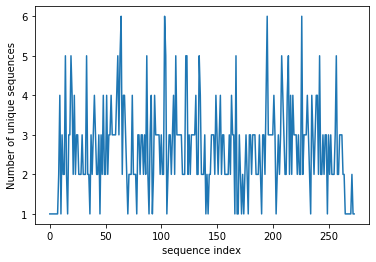

In [6]:
# Number of unique mutations at each index
num_unique = np.array([len(df.sequence.str.get(i).unique()) for i in range(N)])
plt.plot(num_unique)
plt.xlabel("sequence index")
plt.ylabel("Number of unique sequences");

In [7]:
len(df.sequence.unique())

805

In [8]:
len(df)

853

In [9]:
# location of the first stop sequence
df["first_stop"] = df.sequence.str.find("*")
print((df.first_stop != (N-1)).sum())
# print out wherever we have a stop in the middle
df[df.first_stop != (N-1)]

43


,sequence,count,response,first_stop
15,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,1631,3,122
18,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,1263,3,122
11,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,101,0,84
26,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,38,0,214
30,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,36,0,84
40,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,32,0,195
92,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,22,0,91
101,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,21,0,212
133,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,17,0,167
146,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,16,0,170


In [10]:
df[df.sequence == WT]

,sequence,count,response,first_stop
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,17456,3,273
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,29398,2,273
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,1124,1,273
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,781,0,273


## Ordinal regression

In [11]:
from sklearn.preprocessing import OneHotEncoder # to create the design matrix
import mord

In [12]:
design_cols = df.sequence.apply(lambda x: pd.Series(list(x)))

# one hot encode the design columns to get a design matrix
enc = OneHotEncoder(
    drop='first', # dropping the first 
    sparse=False ) # setting to False for now
X = enc.fit_transform(design_cols)
print(X.shape)
X

(853, 451)


array([[0., 0., 1., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 1., 0.],
       ...,
       [0., 0., 1., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 1., 0.]])